In [4]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

model_cb = CatBoostRegressor(verbose=0)

model_cb.fit(X_train, y_train)

y_pred_cb = model_cb.predict(X_test)

In [7]:
mse = mean_squared_error(y_test, y_pred_cb)
mae = mean_absolute_error(y_test, y_pred_cb)
r2 = r2_score(y_test, y_pred_cb)

print(f"MSE: {mse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

MSE: 3.391766881318183
MAE: 1.2267212649300536
R2 Score: 0.960770965854151


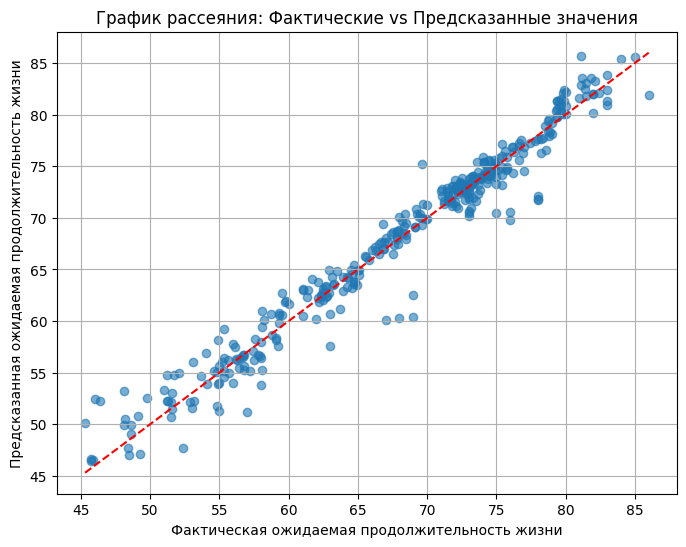

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_cb, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Фактическая ожидаемая продолжительность жизни')
plt.ylabel('Предсказанная ожидаемая продолжительность жизни')
plt.title('График рассеяния: Фактические vs Предсказанные значения')
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\catboost\1.png", dpi=300, bbox_inches="tight")
plt.show()

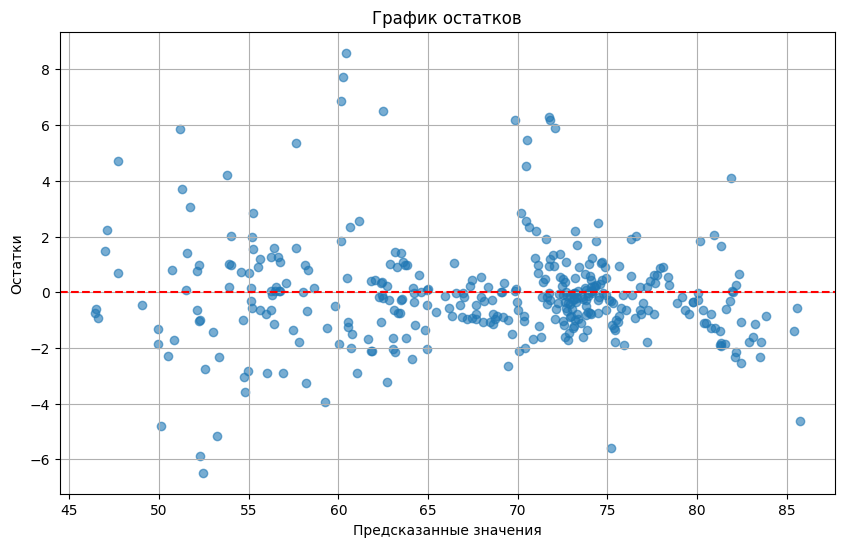

In [9]:
residuals = y_test.values.flatten() - y_pred_cb.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_cb, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\catboost\2.png", dpi=300, bbox_inches="tight")
plt.show()

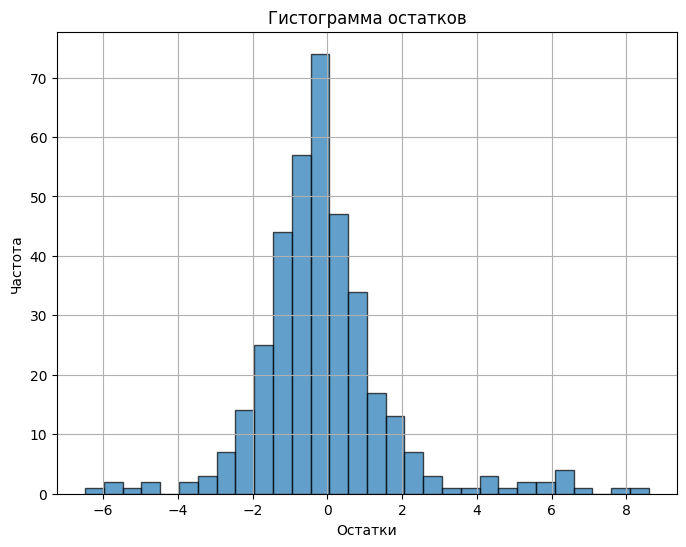

In [10]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7)
plt.title("Гистограмма остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\catboost\3.png", dpi=300, bbox_inches="tight")
plt.show()

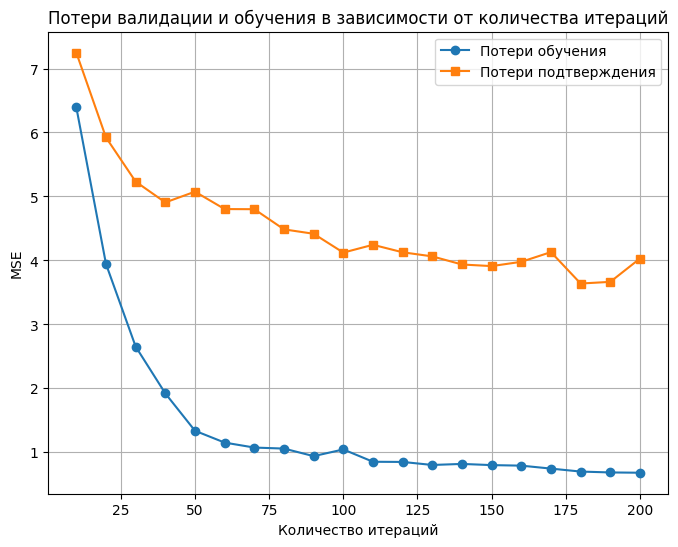

In [11]:
train_losses = []
val_losses = []

for iterations in range(10, 210, 10):
    temp_model = CatBoostRegressor(iterations=iterations, verbose=0)
    temp_model.fit(X_train, y_train)
    train_loss = mean_squared_error(y_train, temp_model.predict(X_train))
    val_loss = mean_squared_error(y_test, temp_model.predict(X_test))
    train_losses.append(train_loss)
    val_losses.append(val_loss)

plt.figure(figsize=(8, 6))
plt.plot(range(10, 210, 10), train_losses, marker='o', label='Потери обучения')
plt.plot(range(10, 210, 10), val_losses, marker='s', label='Потери подтверждения')
plt.title('Потери валидации и обучения в зависимости от количества итераций')
plt.xlabel('Количество итераций')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

plt.savefig(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\catboost\4.png", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
import json

metrics = {
    "MAE": mae,
    "MSE": mse,
    "R2": r2
}

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\metrics\catboost_metrics.json", "w") as f:
    json.dump(metrics, f)

In [13]:
import pickle

with open(r"C:\Users\kseni\PycharmProjects\tpu-8e21-ai-basis\Fomina\jupyter\models\catboost_model.pkl", "wb") as f:
    pickle.dump(model_cb, f)